# Reinforcement Learning: Q-Learning with OpenAI Gymnasium

**Environment:** `Taxi-v3` — A 5×5 grid where a taxi must pick up and drop off a passenger at the correct location.

---

## Table of Contents
- [Part A: Explore the Environment](#part-a)
- [Part B: Implement Q-Learning](#part-b)
- [Part C: Evaluate and Visualize](#part-c)
- [Part D: Reflection](#part-d)

## Setup & Imports

In [1]:
!pip install gymnasium --quiet

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


---
<a id='part-a'></a>
## Part A: Explore the Gym Environment

### Environment: `Taxi-v3`

The **Taxi-v3** environment is a classic discrete RL problem:
- A taxi moves around a 5x5 grid
- It must **pick up** a passenger from one of 4 locations (R, G, Y, B)
- Then **drop them off** at the correct destination
- **State space:** 500 discrete states (25 taxi positions x 5 passenger locations x 4 destinations)
- **Action space:** 6 actions (N, S, E, W, Pick up, Drop off)

**Rewards:**
- `-1` per step
- `+20` for a successful drop-off
- `-10` for illegal pick-up or drop-off

In [3]:
env = gym.make("Taxi-v3")

n_states  = env.observation_space.n
n_actions = env.action_space.n

print(f"Number of states  : {n_states}")
print(f"Number of actions : {n_actions}")
print(f"Observation space : {env.observation_space}")
print(f"Action space      : {env.action_space}")
print()

action_labels = ["Move South", "Move North", "Move East", "Move West", "Pick Up", "Drop Off"]
print("Action meanings:")
for i, label in enumerate(action_labels):
    print(f"  {i}: {label}")

Number of states  : 500
Number of actions : 6
Observation space : Discrete(500)
Action space      : Discrete(6)

Action meanings:
  0: Move South
  1: Move North
  2: Move East
  3: Move West
  4: Pick Up
  5: Drop Off


In [4]:
obs, info = env.reset(seed=42)
print(f"Initial observation (state): {obs}")
print(f"Info: {info}")
print()

print("Taking 5 random actions:")
print("-" * 55)
print(f"{'Step':<6} {'Action':<14} {'New State':<12} {'Reward':<8} {'Done'}")
print("-" * 55)

for step in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print(f"{step+1:<6} {action_labels[action]:<14} {obs:<12} {reward:<8} {done}")
    if done:
        obs, info = env.reset()

env.close()
print("-" * 55)

Initial observation (state): 386
Info: {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}

Taking 5 random actions:
-------------------------------------------------------
Step   Action         New State    Reward   Done
-------------------------------------------------------
1      Move North     286          -1       False
2      Drop Off       286          -10      False
3      Move North     186          -1       False
4      Drop Off       186          -10      False
5      Move South     286          -1       False
-------------------------------------------------------


---
<a id='part-b'></a>
## Part B: Implement Q-Learning

### The Q-Learning Update Rule (Bellman Equation)

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Where:
- $\alpha$ = learning rate
- $\gamma$ = discount factor
- $r$ = reward received
- $s'$ = next state
- $\max_{a'} Q(s', a')$ = best possible future Q-value

### Epsilon-Greedy Strategy
With probability $\varepsilon$, take a random action (explore); otherwise pick the action with the highest Q-value (exploit).

In [5]:
ALPHA         = 0.8
GAMMA         = 0.95
EPSILON       = 1.0
EPSILON_MIN   = 0.01
EPSILON_DECAY = 0.995
N_EPISODES    = 5000
MAX_STEPS     = 200

print(f"alpha={ALPHA}, gamma={GAMMA}, epsilon={EPSILON}, decay={EPSILON_DECAY}")
print(f"episodes={N_EPISODES}, max_steps={MAX_STEPS}")

alpha=0.8, gamma=0.95, epsilon=1.0, decay=0.995
episodes=5000, max_steps=200


In [6]:
Q_table = np.zeros((n_states, n_actions))
print(f"Q-table initialized with shape: {Q_table.shape}")

Q-table initialized with shape: (500, 6)


In [7]:
env = gym.make("Taxi-v3")

rewards_per_episode = []
steps_per_episode   = []
epsilon_per_episode = []
epsilon = EPSILON

for episode in range(N_EPISODES):
    state, _ = env.reset()
    total_reward = 0
    step = 0

    for step in range(MAX_STEPS):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        best_next_q = np.max(Q_table[next_state])
        td_target   = reward + GAMMA * best_next_q * (not done)
        td_error    = td_target - Q_table[state, action]
        Q_table[state, action] += ALPHA * td_error

        total_reward += reward
        state = next_state

        if done:
            break

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(step + 1)
    epsilon_per_episode.append(epsilon)

    if (episode + 1) % 500 == 0:
        recent_avg = np.mean(rewards_per_episode[-500:])
        print(f"Episode {episode+1:>5}/{N_EPISODES} | Avg Reward (last 500): {recent_avg:>7.2f} | Epsilon: {epsilon:.4f}")

env.close()
print("Training complete!")

Episode   500/5000 | Avg Reward (last 500): -172.04 | Epsilon: 0.0816
Episode  1000/5000 | Avg Reward (last 500):    5.95 | Epsilon: 0.0100
Episode  1500/5000 | Avg Reward (last 500):    7.04 | Epsilon: 0.0100
Episode  2000/5000 | Avg Reward (last 500):    7.11 | Epsilon: 0.0100
Episode  2500/5000 | Avg Reward (last 500):    7.29 | Epsilon: 0.0100
Episode  3000/5000 | Avg Reward (last 500):    7.48 | Epsilon: 0.0100
Episode  3500/5000 | Avg Reward (last 500):    7.26 | Epsilon: 0.0100
Episode  4000/5000 | Avg Reward (last 500):    7.34 | Epsilon: 0.0100
Episode  4500/5000 | Avg Reward (last 500):    7.18 | Epsilon: 0.0100
Episode  5000/5000 | Avg Reward (last 500):    7.67 | Epsilon: 0.0100
Training complete!


---
<a id='part-c'></a>
## Part C: Evaluate and Visualize

In [8]:
env = gym.make("Taxi-v3")
N_EVAL_EPISODES = 200
eval_rewards = []
eval_steps   = []
successes    = 0

for episode in range(N_EVAL_EPISODES):
    state, _ = env.reset()
    total_reward = 0

    for step in range(MAX_STEPS):
        action = np.argmax(Q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            if reward == 20:
                successes += 1
            break

    eval_rewards.append(total_reward)
    eval_steps.append(step + 1)

env.close()

print(f"Episodes tested   : {N_EVAL_EPISODES}")
print(f"Avg reward        : {np.mean(eval_rewards):.2f}")
print(f"Avg steps/episode : {np.mean(eval_steps):.2f}")
print(f"Successful trips  : {successes}/{N_EVAL_EPISODES} ({successes/N_EVAL_EPISODES*100:.1f}%)")

Episodes tested   : 200
Avg reward        : 7.65
Avg steps/episode : 13.35
Successful trips  : 200/200 (100.0%)


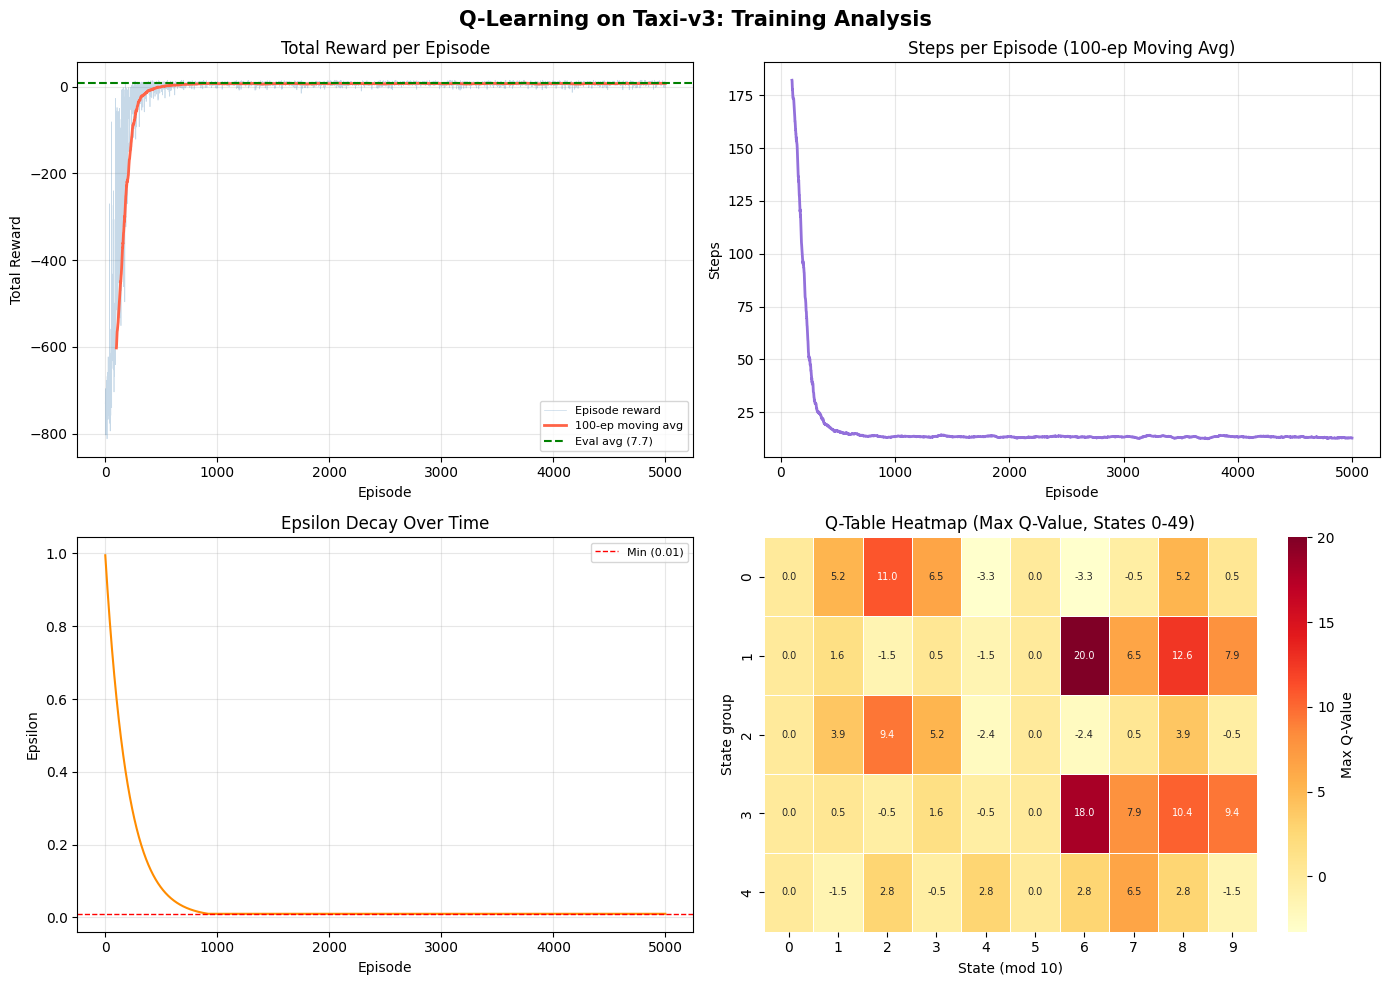

In [9]:
rewards_array = np.array(rewards_per_episode)
window = 100
moving_avg = np.convolve(rewards_array, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Q-Learning on Taxi-v3: Training Analysis", fontsize=15, fontweight='bold')

ax1 = axes[0, 0]
ax1.plot(rewards_array, alpha=0.3, color='steelblue', linewidth=0.5, label='Episode reward')
ax1.plot(np.arange(window-1, N_EPISODES), moving_avg, color='tomato', linewidth=2, label=f'{window}-ep moving avg')
ax1.axhline(y=np.mean(eval_rewards), color='green', linestyle='--', linewidth=1.5, label=f'Eval avg ({np.mean(eval_rewards):.1f})')
ax1.set_title("Total Reward per Episode")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Reward")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
steps_array = np.array(steps_per_episode)
steps_ma = np.convolve(steps_array, np.ones(window)/window, mode='valid')
ax2.plot(np.arange(window-1, N_EPISODES), steps_ma, color='mediumpurple', linewidth=2)
ax2.set_title(f"Steps per Episode ({window}-ep Moving Avg)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Steps")
ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(epsilon_per_episode, color='darkorange', linewidth=1.5)
ax3.set_title("Epsilon Decay Over Time")
ax3.set_xlabel("Episode")
ax3.set_ylabel("Epsilon")
ax3.axhline(y=EPSILON_MIN, color='red', linestyle='--', linewidth=1, label=f'Min ({EPSILON_MIN})')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
max_q_sample = np.max(Q_table[:50], axis=1).reshape(5, 10)
sns.heatmap(max_q_sample, ax=ax4, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Max Q-Value'}, annot_kws={'size': 7})
ax4.set_title("Q-Table Heatmap (Max Q-Value, States 0-49)")
ax4.set_xlabel("State (mod 10)")
ax4.set_ylabel("State group")

plt.tight_layout()
plt.savefig("qlearning_results.png", dpi=150, bbox_inches='tight')
plt.show()

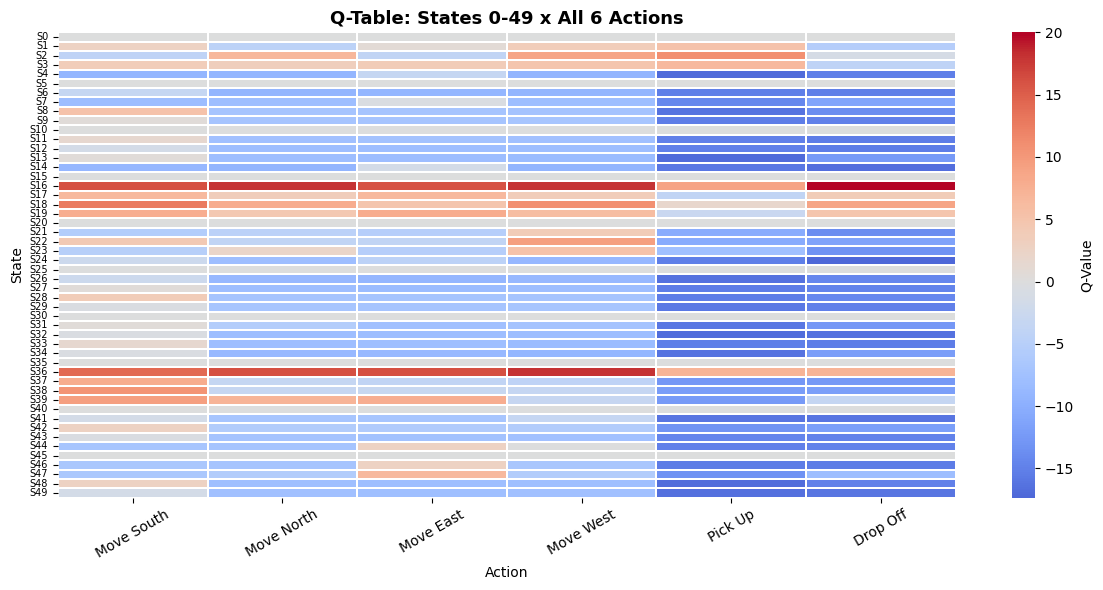

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

q_sample = Q_table[:50]
sns.heatmap(q_sample, ax=ax, cmap='coolwarm', center=0,
            xticklabels=action_labels,
            yticklabels=[f"S{i}" for i in range(50)],
            linewidths=0.2, cbar_kws={'label': 'Q-Value'})

ax.set_title("Q-Table: States 0-49 x All 6 Actions", fontsize=13, fontweight='bold')
ax.set_xlabel("Action")
ax.set_ylabel("State")
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig("qtable_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

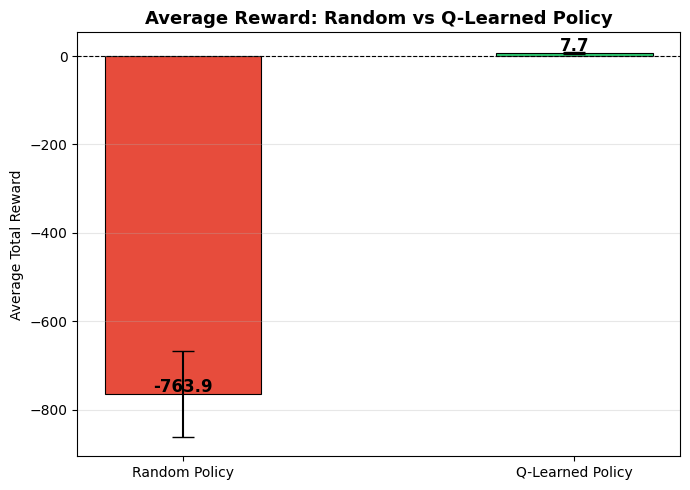

Random Policy    — Mean: -763.90, Std: 97.70
Q-Learned Policy — Mean: 7.65, Std: 2.46
Improvement: 771.55 reward points


In [11]:
env_cmp = gym.make("Taxi-v3")
N_CMP = 200

random_rewards = []
for _ in range(N_CMP):
    state, _ = env_cmp.reset()
    total = 0
    for _ in range(MAX_STEPS):
        state, r, term, trunc, _ = env_cmp.step(env_cmp.action_space.sample())
        total += r
        if term or trunc:
            break
    random_rewards.append(total)

env_cmp.close()

labels = ['Random Policy', 'Q-Learned Policy']
means  = [np.mean(random_rewards), np.mean(eval_rewards)]
stdevs = [np.std(random_rewards),  np.std(eval_rewards)]
colors = ['#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, means, yerr=stdevs, color=colors,
              capsize=8, edgecolor='black', linewidth=0.8, width=0.4)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(stdevs)*0.05,
            f'{mean:.1f}', ha='center', fontweight='bold', fontsize=12)

ax.set_title("Average Reward: Random vs Q-Learned Policy", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Total Reward")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("policy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Random Policy    — Mean: {np.mean(random_rewards):.2f}, Std: {np.std(random_rewards):.2f}")
print(f"Q-Learned Policy — Mean: {np.mean(eval_rewards):.2f}, Std: {np.std(eval_rewards):.2f}")
print(f"Improvement: {np.mean(eval_rewards) - np.mean(random_rewards):.2f} reward points")

---
<a id='part-d'></a>
## Part D: Reflection

### 1. Challenges Encountered in Training

**Exploration vs. Exploitation Balance:**  
The most significant challenge was calibrating the epsilon-greedy strategy. Early in training, the agent needs to explore broadly to even discover that the +20 reward exists. Setting epsilon too low too early caused it to get stuck repeating the same suboptimal actions.

**Delayed Rewards:**  
The +20 reward only arrives after a multi-step sequence: navigate to passenger, pick up, navigate to destination, drop off. The agent has to string together correct decisions across many steps before getting any positive feedback, which made learning slow at first. This is the credit assignment problem — figuring out which earlier actions were responsible for a reward that came much later.

**Convergence Time:**  
Looking at the moving average plot, the agent starts improving around episode 1,000 but doesn't really stabilize until around episode 3,000-4,000. I had to be patient and not stop training too early.

---

### 2. Effect of Hyperparameters

| Hyperparameter | Low Value Effect | High Value Effect | Chosen Value |
|---|---|---|---|
| **Alpha (α)** | Slow learning, may never converge | Unstable, oscillates | 0.8 |
| **Gamma (γ)** | Ignores future rewards, poor planning | Overweights uncertain future | 0.95 |
| **Epsilon (ε)** | Exploits too early, local optima | Explores too long, slow convergence | 1.0 → 0.01 (decaying) |
| **Epsilon decay** | Too much exploration late in training | Premature exploitation | 0.995 |

I chose a high alpha (0.8) because Taxi-v3 is deterministic — the same action in the same state always gives the same result, so aggressive updates are fine. In a stochastic environment I would lower it to avoid overwriting good Q-values with noisy samples.

---

### 3. Real-World Applications of Q-Learning / RL

| Domain | Application |
|---|---|
| **Robotics** | Teaching robotic arms to manipulate objects through trial-and-error |
| **Healthcare** | Personalized treatment planning — dosages that maximize long-term outcomes |
| **Finance** | Trading agents that learn optimal buy/sell timing from market data |
| **Supply Chain** | Inventory management balancing holding costs vs. stockouts |
| **Game AI** | DeepMind's AlphaGo and OpenAI Five both use RL to master complex games |
| **Energy** | Google's DeepMind used RL to cut data center cooling energy by ~40% |

Q-Learning works best when the state and action spaces are discrete and finite. For continuous spaces (like controlling a robot's joints), you'd need something like a Deep Q-Network (DQN) that replaces the table with a neural network.

---

### Summary

Over 5,000 training episodes the agent went from completely random behavior to reliably solving the Taxi task. The comparison chart makes it clear how much better the learned policy is versus just taking random actions. The main takeaway for me is that Q-Learning is surprisingly simple to implement but requires careful tuning of the exploration strategy and enough episodes to actually converge.

In [12]:
print(f"Environment        : Taxi-v3")
print(f"Training episodes  : {N_EPISODES}")
print(f"alpha={ALPHA}, gamma={GAMMA}, epsilon_decay={EPSILON_DECAY}")
print()
print(f"Training avg reward (last 500 eps) : {np.mean(rewards_per_episode[-500:]):.2f}")
print(f"Greedy policy avg reward           : {np.mean(eval_rewards):.2f}")
print(f"Success rate                       : {successes/N_EVAL_EPISODES*100:.1f}%")
print(f"Random policy avg reward           : {np.mean(random_rewards):.2f}")
print(f"Improvement over random            : +{np.mean(eval_rewards)-np.mean(random_rewards):.2f}")

Environment        : Taxi-v3
Training episodes  : 5000
alpha=0.8, gamma=0.95, epsilon_decay=0.995

Training avg reward (last 500 eps) : 7.67
Greedy policy avg reward           : 7.65
Success rate                       : 100.0%
Random policy avg reward           : -763.90
Improvement over random            : +771.55
